In [1]:
from pathlib import Path
from typing import Any
import numpy as np
from dataclasses import dataclass

from my_types import Quat, ScalarBatch, Vec3Batch, QuatBatch
from io_csv import load_gyro_base, load_ref, load_acc, load_grav_ref, load_acc_lin_ref
from pipelines import integrate_gyro_acc
from evaluation import calc_angle_err, print_err_status, score_angle_err, save_err_csv
from evaluation import plot_err_from_csv, plot_quasi_static_diagnostic, plot_err_colored_by_weight
from evaluation import save_estimated_vec3_csv, evaluate_estimated_vec3_autosign, calc_vec3_direction_angle_err
from resample import find_stable_start_idx, cut_sample
from autotune import auto_setup_imu_frame, suggest_fixed_gate_sigma, quasi_static_detector
from optuna_exp_2 import exp_2_1, exp_2_2, exp_2_3, exp_2_4
from Tee import Tee

SIGMA_FLOOR: float = 1e-3
EPS: float = 1e-9

In [2]:
sample_1: str = "data01_21:08_oct_07_2025_5min"
sample_2: str = "data02_21:23_oct_07_2025_9min"
sample_3: str = "data03_21:41_oct_07_2025_13min"
sample_4: str = "data04_18:52_oct_08_2025_96min"

sample: str = sample_1

root: Path = Path.cwd().parent
run_dir: Path = root / "data" / sample

ori_path: Path = run_dir / "Orientation.csv"
gyro_path: Path = run_dir / "Gyroscope.csv"
acc_path: Path = run_dir / "AccelerometerUncalibrated.csv"
grav_path: Path = run_dir / "Gravity.csv"
acc_lin_path: Path = run_dir / "Accelerometer.csv"

for p in [ori_path, gyro_path, acc_path, grav_path, acc_lin_path]:
        if not p.exists():
                raise FileNotFoundError(f"File not found: {p}")

out_dir: Path = root / "output" / sample
out_dir.mkdir(parents=True, exist_ok=True)

path_log: Path = out_dir / "02_exp2_log.txt"
path_err_1: Path = out_dir / "02_exp2-1_angle_err.csv"
path_err_2: Path = out_dir / "02_exp2-2_angle_err.csv"
path_err_3: Path = out_dir / "02_exp2-3_angle_err.csv"
path_err_4: Path = out_dir / "02_exp2-4_angle_err.csv"

path_plot_quasi_static: Path = out_dir / "02_exp2_quasi_static.png"
path_plot: Path = out_dir / "02_exp2_plot.png"
path_plot_weight: Path = out_dir / "02_exp2_plot_weight.png"

path_est_grav: Path = out_dir / "02_exp2_grav_est.csv"
path_est_acc: Path = out_dir / "02_exp2_acc_lin_est.csv"


for p in [path_log, path_err_1, path_err_2, path_err_3, path_err_4,
          path_plot_quasi_static, path_plot, path_plot_weight,
          path_est_grav, path_est_acc]:
        if p.is_file():
                p.unlink()

In [3]:
with Tee(path_log):
        t_src_gyro, w_src_gyro, dt, t_new, w_avg_gyro = load_gyro_base(gyro_path)

        q_ref_interp = load_ref(ori_path, t_new)
        q_ref_interp /= np.linalg.norm(q_ref_interp, axis=1, keepdims=True)

        g_ref_interp = load_grav_ref(grav_path, t_new)
        a_lin_ref_interp = load_acc_lin_ref(acc_lin_path, t_new)

        idx_cut: int = find_stable_start_idx(dt, w_avg_gyro, q_ref_interp,
                                             sample_window=1000, threshold=0.5, sample_hz=100,
                                             consecutive=3, min_cut_second=10, max_cut_second=30)
        t_cut: int = idx_cut / 100
        a_src_interp = load_acc(acc_path, t_new)
        [dt, t_new, w_avg_gyro, q_ref_interp, a_src_interp,
         g_ref_interp, a_lin_ref_interp] = cut_sample(idx_cut,
                                                      [dt, t_new, w_avg_gyro, q_ref_interp, a_src_interp,
                                                       g_ref_interp, a_lin_ref_interp])



[START] 2026-03-17 14:28:16.504

[INFO] Stabilization detected too early (< min_cut), applying min_cut=10s policy

[END] 2026-03-17 14:28:17.130




In [4]:
with Tee(path_log):
        q0: Quat = q_ref_interp[0].copy()
        g0: float = 9.80665
        a_src_interp, g_world_unit = auto_setup_imu_frame(q_ref_interp, w_avg_gyro, dt,
                                                          g0, a_src_interp)
        print("")

        best_quasi_static = quasi_static_detector(w_avg_gyro, a_src_interp, dt, g0,
                                                  w_thr=4, a_thr=4,
                                                  min_duration_s=0.5, smooth_win=5)
        print("")

        gyro_gate_sigma, acc_gate_sigma, _ = suggest_fixed_gate_sigma(
                                                                w_avg_gyro, a_src_interp, None,
                                                                g0, None,
                                                                p_gyro=90, p_acc=90, p_mag=None, sigma_floor=SIGMA_FLOOR,
                                                                best_quasi_static=best_quasi_static)



[START] 2026-03-17 14:28:17.145

Detected accel unit in [m/s²]
Selected g_world_unit: [ 0  0 -1]

Best quasi static(start, end, length):  (2523, 3540, 1017)

Suggested gyro_sigma:  0.44791971689543864
Suggested acc_sigma:  2.908568806018301

[END] 2026-03-17 14:28:17.969




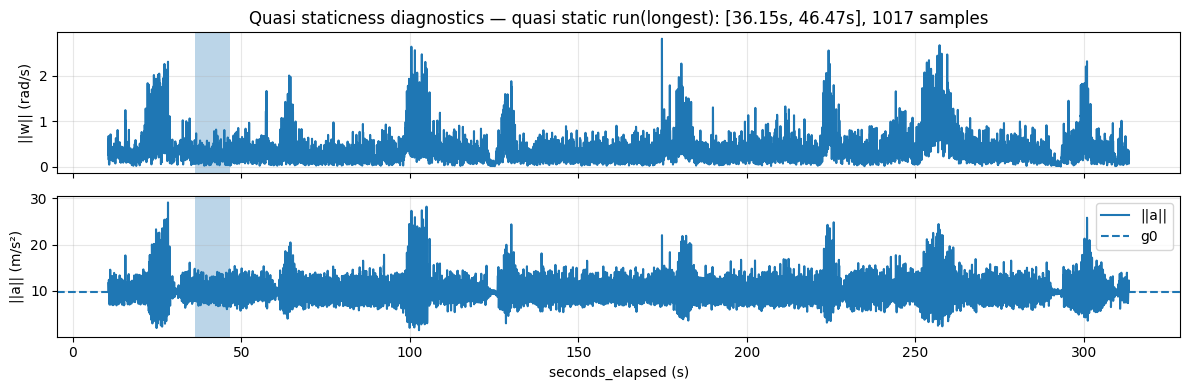

In [5]:
plot_quasi_static_diagnostic(t_new, w_avg_gyro, a_src_interp, g0,
                             best_quasi_static,
                             path_plot_quasi_static)

In [6]:
def runner_exp2(*,
               K: float,
               acc_gate_sigma: float = np.inf,
               gyro_gate_sigma: float = np.inf,
               **kwargs: Any):
        q_est, g_body_est, a_lin_est, weight_acc, weight_gyro = integrate_gyro_acc(
                                                        q0, w_avg_gyro, dt,
                                                        K, g0, g_world_unit,
                                                        acc_gate_sigma, gyro_gate_sigma, a_src_interp)
        weight_mag = np.zeros((len(dt),))
        return q_est, (g_body_est, a_lin_est, weight_acc, weight_gyro, weight_mag)

In [7]:
@dataclass
class Data:
        exp: str
        q_est: QuatBatch
        g_body_est: Vec3Batch
        a_lin_est: Vec3Batch
        weight_acc: ScalarBatch
        weight_gyro: ScalarBatch
        angle_err: ScalarBatch

In [8]:
## exp 2-1: Gyro+Acc without any gating

with Tee(path_log):
        best_tau_1, best_K_1 = exp_2_1(dt=dt,
                                       best_quasi_static=best_quasi_static,
                                       tau_candidate=(0.1, 4),
                                       runner_func=runner_exp2,
                                       n_trials=15)

        print("\n[chosen value]")
        print("tau=", best_tau_1, ", K=", best_K_1)
        print(f"acc_gate_sigma=inf")
        print(f"gyro_gate_sigma=inf\n")

        q_est_1, g_body_est_1, a_lin_est_1, weight_acc_1, weight_gyro_1 = integrate_gyro_acc(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_1, g0, g_world_unit,
                                                        np.inf, np.inf, a_src_interp)

        angle_err_1: ScalarBatch = calc_angle_err(q_est_1, q_ref_interp)
        print_err_status("[exp 2-1] Gyro+Acc", angle_err_1)

        data_exp1: Data = Data("[exp2-1] ", q_est_1, g_body_est_1, a_lin_est_1,
                               weight_acc_1, weight_gyro_1, angle_err_1)

[I 2026-03-17 14:28:19,283] A new study created in memory with name: no-name-85a7e229-e8b6-41f5-9ee4-02b4080dda60




[START] 2026-03-17 14:28:19.282



[I 2026-03-17 14:28:25,293] Trial 0 finished with value: 0.053431676991685495 and parameters: {'tau': 1.5607064635047139}. Best is trial 0 with value: 0.053431676991685495.
[I 2026-03-17 14:28:30,572] Trial 1 finished with value: 0.046404750913699624 and parameters: {'tau': 3.807785794998673}. Best is trial 1 with value: 0.046404750913699624.
[I 2026-03-17 14:28:35,835] Trial 2 finished with value: 0.04872872049631986 and parameters: {'tau': 2.95477637306448}. Best is trial 1 with value: 0.046404750913699624.
[I 2026-03-17 14:28:41,063] Trial 3 finished with value: 0.05042486875151989 and parameters: {'tau': 2.434768088368443}. Best is trial 1 with value: 0.046404750913699624.
[I 2026-03-17 14:28:46,152] Trial 4 finished with value: 0.05081701467165762 and parameters: {'tau': 0.7084726977255024}. Best is trial 1 with value: 0.046404750913699624.
[I 2026-03-17 14:28:51,094] Trial 5 finished with value: 0.0508157176257802 and parameters: {'tau': 0.7083786293111903}. Best is trial 1 with 


[chosen value]
tau= 3.9647925622032214 , K= 0.0025218921645985665
acc_gate_sigma=inf
gyro_gate_sigma=inf

[exp 2-1] Gyro+Acc angle error in rad — min/max/mean/p90
0.002792569731405555 1.4026426778532652 0.3398619909190511 0.51315497786888

[exp 2-1] Gyro+Acc angle error in deg — min/max/mean/p90
0.1600024596055202 80.36550560592005 19.47265769657514 29.401614468015985

[END] 2026-03-17 14:29:43.501




In [9]:
# exp 2-2: Gyro+Acc+Gating(Acc) — fixed sigma

with Tee(path_log):
        best_tau_2, best_K_2, best_acc_sigma_2 = exp_2_2(dt=dt, q_ref=q_ref_interp,
                                                         best_quasi_static=best_quasi_static,
                                                         tau_candidate=(best_tau_1 * 0.9, best_tau_1 * 1.1),
                                                         acc_gate_sigma_candidate=(0.01 * acc_gate_sigma, 10 * acc_gate_sigma),
                                                         runner_func=runner_exp2,
                                                         n_trials=20)

        print("\n[chosen value]")
        print("tau=", best_tau_2, ", K=", best_K_2)
        print(f"acc_gate_sigma={best_acc_sigma_2:.7f}")
        print(f"gyro_gate_sigma=inf\n")

        q_est_2, g_body_est_2, a_lin_est_2, weight_acc_2, weight_gyro_2 = integrate_gyro_acc(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_2, g0, g_world_unit,
                                                        best_acc_sigma_2, np.inf, a_src_interp)
        angle_err_2: ScalarBatch = calc_angle_err(q_est_2, q_ref_interp)
        print_err_status("[exp 2-2] Gyro+Acc+Gating(Acc) — fixed sigma", angle_err_2)

        data_exp2: Data = Data("[exp2-2] ", q_est_2, g_body_est_2, a_lin_est_2,
                               weight_acc_2, weight_gyro_2, angle_err_2)

[I 2026-03-17 14:29:43,524] A new study created in memory with name: no-name-142c9a14-d1e7-456d-b0ee-6aa9ea5ce054




[START] 2026-03-17 14:29:43.522



[I 2026-03-17 14:29:51,251] Trial 0 finished with value: 0.600338795332012 and parameters: {'tau': 3.865308081473446, 'acc_gate_sigma': 27.65361325890166}. Best is trial 0 with value: 0.600338795332012.
[I 2026-03-17 14:29:58,660] Trial 1 finished with value: 0.5994808069232679 and parameters: {'tau': 4.148754133197235, 'acc_gate_sigma': 17.42406722007125}. Best is trial 1 with value: 0.5994808069232679.
[I 2026-03-17 14:30:06,069] Trial 2 finished with value: 0.598979666560321 and parameters: {'tau': 3.6920296150211454, 'acc_gate_sigma': 4.561756437699252}. Best is trial 2 with value: 0.598979666560321.
[I 2026-03-17 14:30:13,451] Trial 3 finished with value: 0.6010981968413369 and parameters: {'tau': 3.614371200684974, 'acc_gate_sigma': 25.197221540060372}. Best is trial 2 with value: 0.598979666560321.
[I 2026-03-17 14:30:20,750] Trial 4 finished with value: 0.599790703268116 and parameters: {'tau': 4.0449725715005345, 'acc_gate_sigma': 20.603269031683883}. Best is trial 2 with valu


[chosen value]
tau= 4.026772033847807 , K= 0.0024830755783621017
acc_gate_sigma=2.9133442
gyro_gate_sigma=inf

[exp 2-2] Gyro+Acc+Gating(Acc) — fixed sigma angle error in rad — min/max/mean/p90
0.002748354142392041 1.401548675497198 0.33849208040378065 0.5120721420212044

[exp 2-2] Gyro+Acc+Gating(Acc) — fixed sigma angle error in deg — min/max/mean/p90
0.15746909296636083 80.30282388814003 19.39416760573955 29.339572544038706

[END] 2026-03-17 14:32:22.062




In [10]:
# exp 2-3: Gyro+Acc+Gating(Gyro/Acc) — fixed sigma

with Tee(path_log):
        [best_tau_3, best_K_3,
         best_acc_sigma_3, best_gyro_sigma_3] = exp_2_3(dt=dt, q_ref=q_ref_interp,
                                                        best_quasi_static=best_quasi_static,
                                                        tau_candidate=(best_tau_2 * 0.9, best_tau_2 * 1.1),
                                                        acc_gate_sigma_candidate=(best_acc_sigma_2 * 0.7, best_acc_sigma_2 * 1.3),
                                                        gyro_gate_sigma_candidate=(0.1 * gyro_gate_sigma, 10 * gyro_gate_sigma),
                                                        runner_func=runner_exp2,
                                                        n_trials=20)

        print("\n[chosen value]")
        print("tau=", best_tau_3, ", K=", best_K_3)
        print(f"acc_gate_sigma={best_acc_sigma_3:.7f}")
        print(f"gyro_gate_sigma={best_gyro_sigma_3:.7f}\n")

        q_est_3, g_body_est_3, a_lin_est_3, weight_acc_3, weight_gyro_3 = integrate_gyro_acc(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_3, g0, g_world_unit,
                                                        best_acc_sigma_3, best_gyro_sigma_3, a_src_interp)
        angle_err_3: ScalarBatch = calc_angle_err(q_est_3, q_ref_interp)
        print_err_status("[exp 2-3] Gyro+Acc+Gating(Gyro/Acc) — fixed sigma", angle_err_3)

        data_exp3: Data = Data("[exp2-3] ", q_est_3, g_body_est_3, a_lin_est_3,
                               weight_acc_3, weight_gyro_3, angle_err_3)

[I 2026-03-17 14:32:22,080] A new study created in memory with name: no-name-09c1a732-a88a-432b-819e-eb0b0a798c6a




[START] 2026-03-17 14:32:22.078



[I 2026-03-17 14:32:29,657] Trial 0 finished with value: 0.5975593753949751 and parameters: {'tau': 3.9257323656887446, 'acc_gate_sigma': 3.7011957257996104, 'gyro_gate_sigma': 3.2907497116244175}. Best is trial 0 with value: 0.5975593753949751.
[I 2026-03-17 14:32:37,878] Trial 1 finished with value: 0.5918446767432848 and parameters: {'tau': 4.106227078861095, 'acc_gate_sigma': 2.3120625279525893, 'gyro_gate_sigma': 0.736534883413237}. Best is trial 1 with value: 0.5918446767432848.
[I 2026-03-17 14:32:45,358] Trial 2 finished with value: 0.5979312477519326 and parameters: {'tau': 3.6708727234837792, 'acc_gate_sigma': 3.5534224706378263, 'gyro_gate_sigma': 2.710379503917546}. Best is trial 1 with value: 0.5918446767432848.
[I 2026-03-17 14:32:53,025] Trial 3 finished with value: 0.5926311794429867 and parameters: {'tau': 4.194344201303754, 'acc_gate_sigma': 2.0753227587664647, 'gyro_gate_sigma': 4.3457652609950665}. Best is trial 1 with value: 0.5918446767432848.
[I 2026-03-17 14:33:


[chosen value]
tau= 4.411902592663294 , K= 0.0022663191416570022
acc_gate_sigma=2.9791675
gyro_gate_sigma=0.1969152

[exp 2-3] Gyro+Acc+Gating(Gyro/Acc) — fixed sigma angle error in rad — min/max/mean/p90
0.00163324271634456 1.4005973749091025 0.3378135110770164 0.510934527798625

[exp 2-3] Gyro+Acc+Gating(Gyro/Acc) — fixed sigma angle error in deg — min/max/mean/p90
0.09357791456702556 80.24831837939384 19.355288447208924 29.27439205037085

[END] 2026-03-17 14:35:06.491




In [11]:
# exp 2-4: Gyro+Acc+Gating(Gyro/Acc) — time-varying sigma

with Tee(path_log):
        [best_tau_4, best_K_4,
         timevarying_acc_sigma_4, timevarying_gyro_sigma_4
         ] = exp_2_4(dt=dt, q_ref=q_ref_interp,
                     g0=g0, sigma_floor=SIGMA_FLOOR,
                     w=w_avg_gyro, a=a_src_interp,
                     best_quasi_static=best_quasi_static,
                     tau_candidate=(best_tau_3 * 0.9, best_tau_3 * 1.1),
                     p_candidate=(50, 80),
                     win_s_candidate=(5, 10),
                     update_ratio_candidate=(0.1, 0.5),
                     ema_candidate=(0.02, 0.2),
                     runner_func=runner_exp2,
                     n_trials=40)

        print("\n[chosen value]")
        print("tau=", best_tau_4, ", K=", best_K_4)
        print("acc_gate_sigma/gyro_gate_sigma = time-varying gate sigma\n")

        q_est_4, g_body_est_4, a_lin_est_4, weight_acc_4, weight_gyro_4 = integrate_gyro_acc(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_4, g0, g_world_unit,
                                                        timevarying_acc_sigma_4, timevarying_gyro_sigma_4, a_src_interp)

        angle_err_4: ScalarBatch = calc_angle_err(q_est_4, q_ref_interp)
        print_err_status("[exp 2-4] Gyro+Acc+Gating(Gyro/Acc) — time varying sigma", angle_err_4)

        data_exp4: Data = Data("[exp2-4] ", q_est_4, g_body_est_4, a_lin_est_4,
                               weight_acc_4, weight_gyro_4, angle_err_4)

[I 2026-03-17 14:35:06,509] A new study created in memory with name: no-name-11fcb646-6425-4dc4-8848-8118f60b38aa




[START] 2026-03-17 14:35:06.507



[I 2026-03-17 14:35:14,462] Trial 0 finished with value: 0.5881685119299408 and parameters: {'tau': 4.3011992376767845, 'p': 79, 'win_s': 8.30466536774918, 'update_ratio': 0.3394633936788146, 'ema_alpha': 0.04808335527963858}. Best is trial 0 with value: 0.5881685119299408.
[I 2026-03-17 14:35:22,512] Trial 1 finished with value: 0.585427600445912 and parameters: {'tau': 4.108358859139477, 'p': 51, 'win_s': 9.114125527116833, 'update_ratio': 0.34044600469728353, 'ema_alpha': 0.1474530640032882}. Best is trial 1 with value: 0.585427600445912.
[I 2026-03-17 14:35:30,453] Trial 2 finished with value: 0.5902146249213042 and parameters: {'tau': 3.9888756901474274, 'p': 80, 'win_s': 8.903488639350979, 'update_ratio': 0.18493564427131048, 'ema_alpha': 0.05272849409727812}. Best is trial 1 with value: 0.585427600445912.
[I 2026-03-17 14:35:38,038] Trial 3 finished with value: 0.5855843116240319 and parameters: {'tau': 4.1325448999026655, 'p': 59, 'win_s': 7.193453335958096, 'update_ratio': 0.2


[chosen value]
tau= 4.502036844330733 , K= 0.0022209456836120994
acc_gate_sigma/gyro_gate_sigma = time-varying gate sigma

[exp 2-4] Gyro+Acc+Gating(Gyro/Acc) — time varying sigma angle error in rad — min/max/mean/p90
0.0027016091819519134 1.400982210449621 0.33899127245759747 0.5110999765456887

[exp 2-4] Gyro+Acc+Gating(Gyro/Acc) — time varying sigma angle error in deg — min/max/mean/p90
0.15479080401963552 80.27036783167219 19.42276920358972 29.28387156530333

[END] 2026-03-17 14:40:26.807




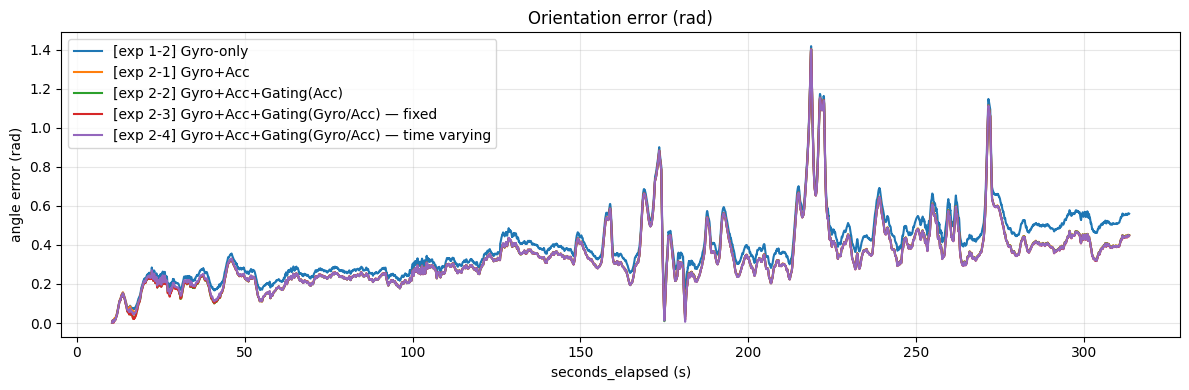

In [12]:
save_err_csv(path_err_1, t_new, data_exp1.angle_err)
save_err_csv(path_err_2, t_new, data_exp2.angle_err)
save_err_csv(path_err_3, t_new, data_exp3.angle_err)
save_err_csv(path_err_4, t_new, data_exp4.angle_err)

path_err_exp1_2 = out_dir / "01_exp1-2_angle_err.csv"

plot_err_from_csv([
        ("[exp 1-2] Gyro-only", path_err_exp1_2),
        ("[exp 2-1] Gyro+Acc", path_err_1),
        ("[exp 2-2] Gyro+Acc+Gating(Acc)", path_err_2),
        ("[exp 2-3] Gyro+Acc+Gating(Gyro/Acc) — fixed", path_err_3),
        ("[exp 2-4] Gyro+Acc+Gating(Gyro/Acc) — time varying", path_err_4)],
                  path_plot)

In [13]:
with Tee(path_log):
        best: Data = None
        for i in [data_exp1, data_exp2, data_exp3, data_exp4]:
                if best is None or score_angle_err(i.angle_err) < score_angle_err(best.angle_err):
                        best = i

        s: str = best.exp
        s = s[s.find('-')-1 : s.find('-')+2]
        print(f"best: exp{s}")

        [min_angle_err,
         w_acc, w_gyro,
         w_total,
         g_est, a_est
         ] = [best.angle_err,
              best.weight_acc, best.weight_gyro,
              best.weight_acc*best.weight_gyro,
              best.g_body_est, best.a_lin_est]



[START] 2026-03-17 14:40:28.735

best: exp2-3

[END] 2026-03-17 14:40:28.743




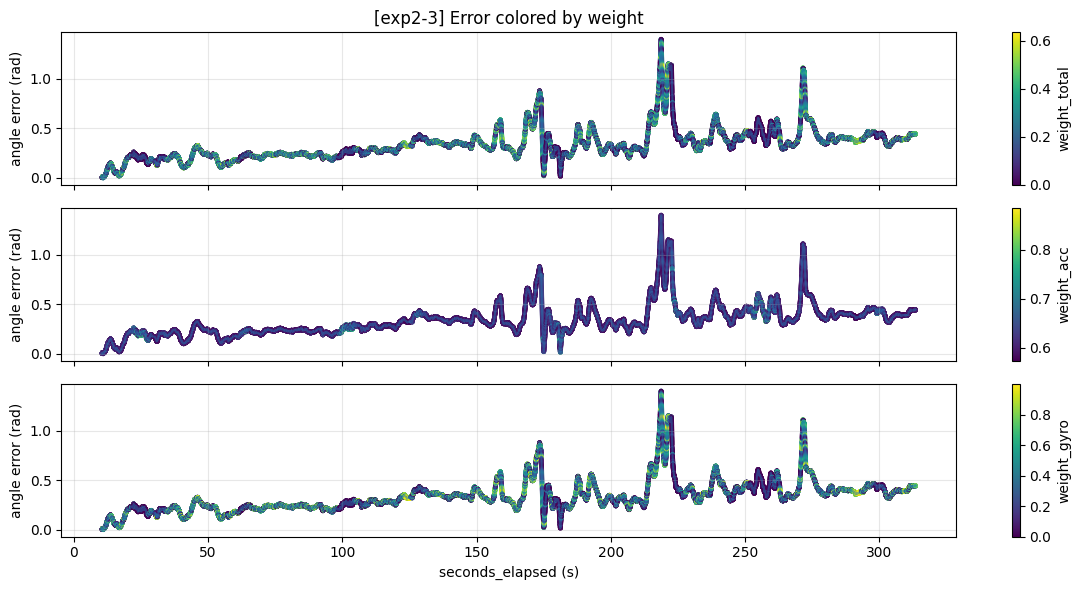

In [14]:
plot_err_colored_by_weight(2, t_new, min_angle_err,
                           w_acc, w_gyro, None, w_total,
                           best.exp, path_plot_weight)

In [15]:
with Tee(path_log):
        print("[Gravity]")
        g_est_sign_fixed, g_rmse_norm = evaluate_estimated_vec3_autosign(g_est, g_ref_interp)
        save_estimated_vec3_csv(path_est_grav, t_new, g_est_sign_fixed)
        err_grav = calc_vec3_direction_angle_err(g_est_sign_fixed, g_ref_interp)
        print("")
        print_err_status("Gravity est/ref", err_grav)
        print("")

        print("\n[Linear accel]")
        a_lin_est_sign_fixed, a_lin_rmse_norm = evaluate_estimated_vec3_autosign(a_est, a_lin_ref_interp)
        save_estimated_vec3_csv(path_est_acc, t_new, a_lin_est_sign_fixed)
        err_acc_lin = calc_vec3_direction_angle_err(a_lin_est_sign_fixed, a_lin_ref_interp)
        print("")
        print_err_status("Linear accel est/ref", err_acc_lin)
        print("")

        print("\n[Consistency ratio]")
        print("rmse_norm of (a_lin_est / g_est): ", a_lin_rmse_norm / max(g_rmse_norm, EPS))



[START] 2026-03-17 14:40:35.309

[Gravity]
RMSE norm: 0.20127494414237856

Gravity est/ref angle error in rad — min/max/mean/p90
4.258330309511835e-05 0.09699583475086833 0.01703841175553693 0.026552023496872593

Gravity est/ref angle error in deg — min/max/mean/p90
0.002439843545076657 5.55745196157312 0.9762290831983539 1.5213188839029932


[Linear accel]
RMSE norm: 0.7422099471787518

Linear accel est/ref angle error in rad — min/max/mean/p90
0.0009246217951388085 3.073500429721502 0.15560836401671843 0.3389448841717979

Linear accel est/ref angle error in deg — min/max/mean/p90
0.052976926507263544 176.09860295468695 8.915702515093352 19.42011135059456


[Consistency ratio]
rmse_norm of (a_lin_est / g_est):  3.6875426811880008

[END] 2026-03-17 14:40:35.820


